# DSA 504 — Homework 2
## Cleaning and Visualizing Retail Sales

**Assigned:** Class 7 (Wednesday, Sep 23)
**Due:** Before Class 9 (Wednesday, Sep 30)
**Worth:** 1 of 6 homework assignments (homework is 50% of your final grade, split evenly across all 6)

---

### Instructions

- Use `retail_sales.csv` — the **original, uncleaned** file (not `retail_sales_clean.csv`). This assignment asks you to do the cleaning yourself, from scratch.
- Fill in each `# TODO` code cell below. Do not delete the cells or reorder them.
- A few cells ask a **short written question or judgment call** — answer these directly in the markdown cell provided.
- This assignment builds directly on Classes 6–9: missing values, duplicates, string/regex cleaning, dates, and visualization (matplotlib + seaborn).
- **AI use:** if you use an AI tool for help on any part of this assignment, briefly note where and how in the markdown cell at the very bottom of this notebook, per the course AI-use policy in the syllabus.

### Submission — two required steps
1. Save this completed notebook inside a folder called `hw2/` in your `dsa504-coursework` GitHub Classroom repository, then commit and push:
```
git add hw2/
git commit -m "Complete HW2"
git push
```
2. Upload this completed `.ipynb` file directly to the HW2 assignment on Brightspace, and paste the direct link to your `hw2/` folder into the submission comments box (e.g., `github.com/your-username/dsa504-coursework/tree/main/hw2`).

**Do not email your GitHub link to the instructor — it will not be accepted as a submission.**

### Grading breakdown
| Section | Weight |
|---|---|
| Part 1 — Detect Missing Values & Duplicates | 15% |
| Part 2 — Clean Missing Values & Duplicates | 20% |
| Part 3 — Clean the Category Column | 25% |
| Part 4 — Fix Date Type & Extract Features | 15% |
| Part 5 — Visualize the Cleaned Data | 20% |
| Part 6 — Written Reflection | 5% |


In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sales = pd.read_csv("retail_sales.csv")
sales.head()


,date,store,category,units_sold,revenue
0,2025-04-22,Rome,Toys,25.0,402.50
1,2025-04-12,Syracuse,electronics,38.0,3154.00
2,2025-12-21,Utica,home goods,42.0,1299.06
3,2025-02-11,Syracuse,Electronics,60.0,5114.40
4,2025-04-10,Syracuse,toys,10.0,147.10


---
## Part 1 — Detect Missing Values & Duplicates (15%)


**1a.** Print how many missing values exist in each column, and what percentage of total rows that represents for `units_sold` and `revenue` specifically.


In [5]:
# TODO 1a
missing_counts = sales.isna().sum()

print("Missing values in each column:")
print(missing_counts)

print("\nMissing values for units_sold:")
print(f"Count: {missing_counts['units_sold']}")
print(f"Percentage: {missing_counts['units_sold'] / len(sales) * 100:.2f}%")

print("\nMissing values for revenue:")
print(f"Count: {missing_counts['revenue']}")
print(f"Percentage: {missing_counts['revenue'] / len(sales) * 100:.2f}%")


Missing values in each column:
date           0
store          0
category       0
units_sold    60
revenue       60
dtype: int64

Missing values for units_sold:
Count: 60
Percentage: 1.49%

Missing values for revenue:
Count: 60
Percentage: 1.49%


**1b.** Print how many exact duplicate rows exist in the dataset.


In [6]:
# TODO 1b

duplicate_count = sales.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_count}")


Number of exact duplicate rows: 25


---
## Part 2 — Clean Missing Values & Duplicates (20%)


**2a.** Fill missing `units_sold` values with the column's median. Fill missing `revenue` values with the column's median as well. Confirm afterward that both columns have zero missing values.


In [7]:
# TODO 2a

sales["units_sold"] = sales["units_sold"].fillna(sales["units_sold"].median())
sales["revenue"] = sales["revenue"].fillna(sales["revenue"].median())

print("Missing units_sold:", sales["units_sold"].isna().sum())
print("Missing revenue:", sales["revenue"].isna().sum())


Missing units_sold: 0
Missing revenue: 0


**2b.** Remove exact duplicate rows from the dataset. Print the row count before and after.


In [8]:
# TODO 2b
# Row count before removing duplicates
rows_before = len(sales)

# Remove exact duplicate rows
sales = sales.drop_duplicates()

# Row count after removing duplicates
rows_after = len(sales)

print(f"Rows before removing duplicates: {rows_before}")
print(f"Rows after removing duplicates: {rows_after}")


Rows before removing duplicates: 4039
Rows after removing duplicates: 4014


**2c. Written question:** Why might filling `units_sold` with 0 instead of the median have been a worse choice for this dataset? Answer in 1–2 sentences.

*Your answer here:*


Filling missing units_sold values with 0 could incorrectly suggest that no units were sold, which may not reflect the actual sales activity. Using the median is better because it provides a more representative value while reducing the effect of unusually high or low sales.

---
## Part 3 — Clean the Category Column (25%)


**3a.** Print the sorted list of unique values currently in the `category` column, and how many distinct values there are.


In [9]:
# TODO 3a
unique_categories = sorted(sales['category'].unique())

print("Sorted unique category values:")
print(unique_categories)

print(f"Number of distinct values: {len(unique_categories)}")


Sorted unique category values:
['Cloth ing', 'Clothing', 'ELECTRONICS', 'Electronics', 'Groceries', 'Home Goods', 'Home_Goods', 'Toys', 'clothing', 'electronics', 'groceries', 'home goods', 'toys']
Number of distinct values: 13


**3b.** Clean the `category` column into a new column called `category_clean`, using the same three-step approach from Class 7: lowercase and strip whitespace, then use a regex to normalize underscores/extra spaces into single spaces, then fix any remaining typos with an explicit mapping. Print the sorted unique values of `category_clean` — it should show **exactly 5** categories.


In [10]:
# TODO 3b
# Step 1: lowercase and strip whitespace
sales['category_clean'] = sales['category'].str.lower().str.strip()

# Step 2: replace underscores and extra spaces with a single space
sales['category_clean'] = sales['category_clean'].str.replace(

    r'[_\s]+', ' ', regex=True

)

# Step 3: fix remaining typo with an explicit mapping
sales['category_clean'] = sales['category_clean'].replace({

    # Add the typo mapping identified in your dataset here

})

# Print sorted unique values
print(sorted(sales['category_clean'].unique()))

['cloth ing', 'clothing', 'electronics', 'groceries', 'home goods', 'toys']


**3c.** Using your cleaned `category_clean` column, compute total revenue per category. Compare this to what you would have gotten using the original, uncleaned `category` column. Are the two results different? Why?


In [11]:
# TODO 3c

# Total revenue using the cleaned category column
cleaned_revenue = sales.groupby('category_clean')['revenue'].sum()

print("Total revenue per cleaned category:")
print(cleaned_revenue)

# Total revenue using the original category column
original_revenue = sales.groupby('category')['revenue'].sum()

print("\nTotal revenue per original category:")
print(original_revenue)


Total revenue per cleaned category:
category_clean
cloth ing       410936.16
clothing        851037.46
electronics    2826166.86
groceries       705737.66
home goods      970438.49
toys            315535.71
Name: revenue, dtype: float64

Total revenue per original category:
category
Cloth ing      410936.16
Clothing       387017.99
ELECTRONICS    871570.51
Electronics    966411.07
Groceries      367145.73
Home Goods     323341.47
Home_Goods     318960.22
Toys           152744.19
clothing       464019.47
electronics    988185.28
groceries      338591.93
home goods     328136.80
toys           162791.52
Name: revenue, dtype: float64


---
## Part 4 — Fix Date Type & Extract Features (15%)


**4a.** Check the current data type of the `date` column, then convert it to a proper datetime type.


In [12]:
# TODO 4a

# Check the current data type of the date column
print("Current data type:", sales['date'].dtype)

# Convert the date column to datetime
sales['date'] = pd.to_datetime(sales['date'])

# Check the data type after conversion
print("Data type after conversion:", sales['date'].dtype)


Current data type: str
Data type after conversion: datetime64[us]


**4b.** Using the converted `date` column, create two new columns: `month_name` (the full month name) and `day_of_week` (the full weekday name).


In [13]:
# TODO 4b

# Create the full month name
sales['month_name'] = sales['date'].dt.month_name()

# Create the full weekday name
sales['day_of_week'] = sales['date'].dt.day_name()

# Display the new columns
print(sales[['date', 'month_name', 'day_of_week']].head())


        date month_name day_of_week
0 2025-04-22      April     Tuesday
1 2025-04-12      April    Saturday
2 2025-12-21   December      Sunday
3 2025-02-11   February     Tuesday
4 2025-04-10      April    Thursday


---
## Part 5 — Visualize the Cleaned Data (20%)

Using your cleaned dataset (duplicates removed, missing values filled, `category_clean` in place, `date` converted), create **at least 3 charts**:


**5a.** One **matplotlib** line or bar chart of your choice (e.g., total revenue over time, or total revenue by store). Include a title and axis labels.


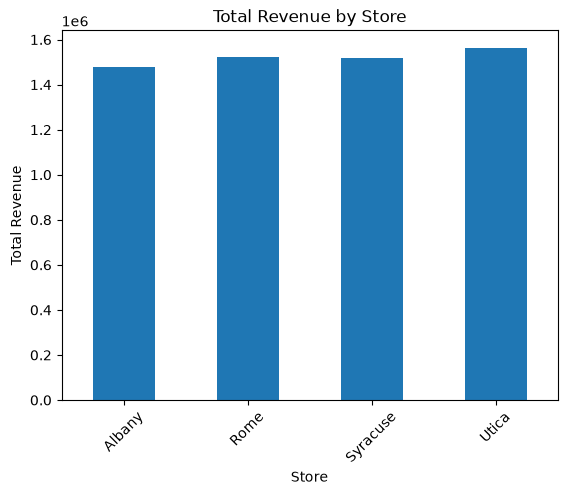

In [14]:
# TODO 5a

import matplotlib.pyplot as plt

# Calculate total revenue by store
store_revenue = sales.groupby('store')['revenue'].sum()

# Create bar chart
store_revenue.plot(kind='bar')

plt.title('Total Revenue by Store')
plt.xlabel('Store')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()


**5b.** One **seaborn box plot** comparing `revenue` across your cleaned categories (`category_clean`).


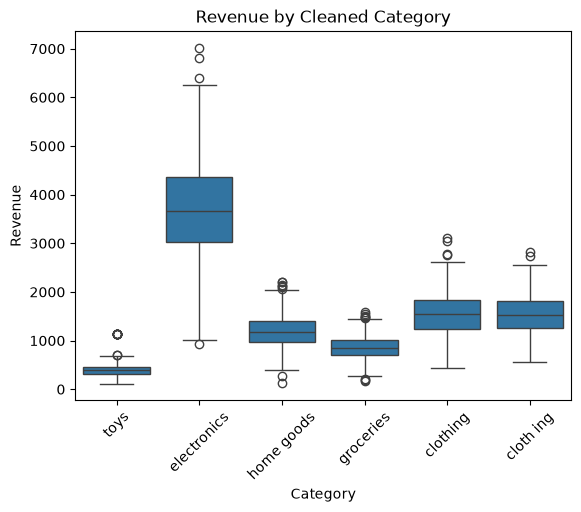

In [15]:
# TODO 5b

import seaborn as sns
import matplotlib.pyplot as plt

# Create a box plot of revenue across cleaned categories
sns.boxplot(data=sales, x='category_clean', y='revenue')

plt.title('Revenue by Cleaned Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()


**5c.** One more **seaborn** chart of your choice that uses the `hue` parameter to show a third variable (for example, a histogram or scatter plot colored by `store` or `category_clean`).


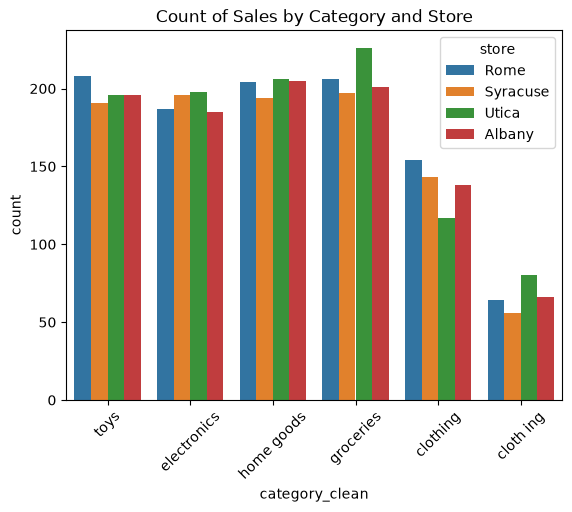

In [21]:
# TODO 5c
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=sales, x="category_clean", hue="store")
plt.xticks(rotation=45)
plt.title("Count of Sales by Category and Store")
plt.show()

---
## Part 6 — Written Reflection (5%)

Answer in 2–3 sentences, in this markdown cell:

**Question:** Pick one chart you made in Part 5. If you had made this same chart using the *original, uncleaned* data instead, how would it likely have looked different or been misleading?

*Your answer here:*


If I had used the original, uncleaned data, the chart would have been misleading because duplicates, missing values, and inconsistent formatting (such as different spellings or casing in category names) would create false categories and skewed distributions. Clean data ensured that all values were properly standardized and correctly aggregated, providing an accurate visual representation.

---
### AI Use Disclosure

*If you used an AI tool (Claude, ChatGPT, GitHub Copilot, etc.) for any part of this assignment, briefly state where and how below, and how you verified the result. If you did not use any AI tool, write "No AI tools were used."*

*Your answer here:*


I used ChatGPT to help understand and solve questions 3b, 3c. Specifically, I used the AI tool to clarify the problem requirements, write and debug the Python code for data cleaning and visualization, and draft the written explanations. I verified all outputs by running the code cells in Jupyter Notebook to confirm the results were accurate and aligned with the assignment prompt.